We check if the fft simulation process gives a trajectory with the same trajectory as the OU simulation one.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import scipy
import scipy.linalg
import math
import gaussian_crossings.utils as utils
import gaussian_crossings.formula as formula
import gaussian_crossings.process as process

In [2]:
# Simulation parameters.
T = 20.0                         # Total simulation time.
omega0 = math.sqrt(10.0)                   # Fundamental frequency
zeta = 0.1                      # Damping ratio
temp = 10.0                     # Temperature (similar to sigma ** 2)

if zeta < 1.0:
    dt = 0.01 / (omega0 * max(zeta, math.sqrt(1 - zeta**2)))  
elif zeta == 1.0:
    dt = 0.01 / omega0
else:
    dt = 0.01 / (omega0 * max(zeta + math.sqrt(zeta**2 - 1), zeta - math.sqrt(zeta**2 - 1)))

In [3]:
# simulation using the fft code
t, x = utils.simulate_gaussian_process_fft(process.r_damped_harmonic_oscillator_noise, T, dt, temp=temp, omega0=omega0, zeta=zeta)

In [4]:
# simulation using the linear system
model = process.damped_harmonic_oscillator_noise(temp=temp, omega0=omega0, zeta=zeta)
t_sim, traj = utils.euler_maruyama_sde(model, time=T, dt=dt)
x_sim = traj[:, 0]

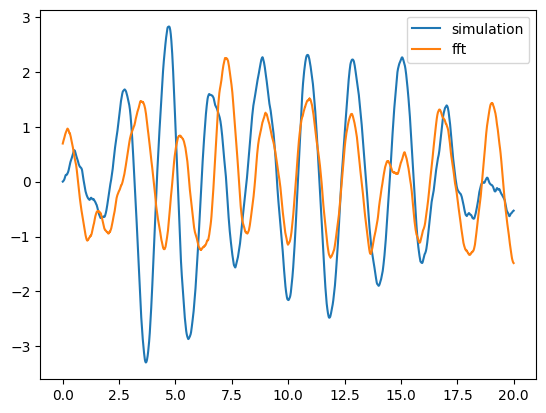

In [5]:
# plot both trajectories on the same plot
plt.plot(t_sim, x_sim, label='simulation')
plt.plot(t, x, label='fft')
plt.legend()
plt.show()

In [6]:
# find the mean and standard deviation of both the trajectories
mean_fft = torch.mean(x)
mean_sim = torch.mean(x_sim)
std_fft = torch.std(x)
std_sim = torch.std(x_sim)
analytical_std = process.r_damped_harmonic_oscillator_noise(torch.tensor([0.0]), temp=temp, zeta=zeta, omega0=omega0) ** 0.5

print(f"Mean of the fft simulation: {mean_fft}")
print(f"Mean of the linear system simulation: {mean_sim}")
print(f"Standard deviation of the fft simulation: {std_fft}")
print(f"Standard deviation of the linear system simulation: {std_sim}")
print(f"Standard deviation actual (formula) {analytical_std.item()}")

Mean of the fft simulation: 0.05381853909526148
Mean of the linear system simulation: 0.020153969526290894
Standard deviation of the fft simulation: 0.9074992407670771
Standard deviation of the linear system simulation: 1.3665695190429688
Standard deviation actual (formula) 0.9999999999999999


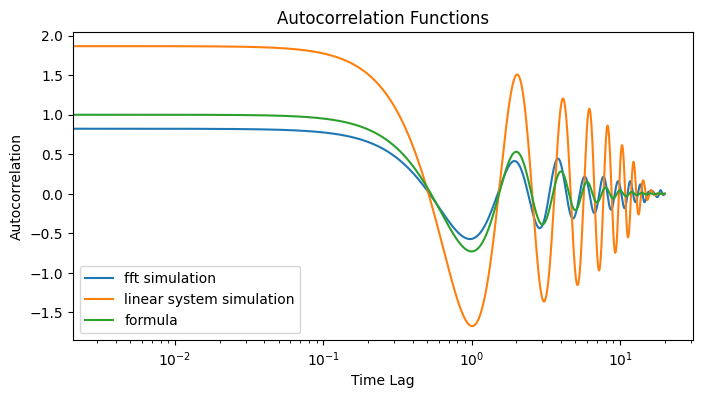

In [7]:
# Compute the autocorrelations.
ac_fft = utils.autocorrelation(x)
ac_sim = utils.autocorrelation(x_sim)

# Create a lag array in time units.
lags_fft = np.arange(len(ac_fft)) * dt  # dt is the time step used in the simulation.
lags_sim = np.arange(len(ac_sim)) * dt  # both should be the same length if simulations are run similarly.

# find the correlation function using the formula
ac_formula = process.r_damped_harmonic_oscillator_noise(torch.from_numpy(lags_fft), zeta=zeta, omega0=omega0, temp=temp)

# Plot both autocorrelation functions on the same plot.
plt.figure(figsize=(8, 4))
plt.plot(lags_fft, ac_fft, label='fft simulation')
plt.plot(lags_sim, ac_sim, label='linear system simulation')
plt.plot(lags_fft, ac_formula, label='formula')
# make x logscale
plt.xscale('log')
plt.xlabel("Time Lag")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation Functions")
plt.legend()
plt.show()

### Averaged across multiple trials

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import gaussian_crossings.utils as utils
import gaussian_crossings.process as process

# Simulation parameters.
T = 20.0                         # Total simulation time.
omega0 = math.sqrt(10.0)                   # Fundamental frequency
zeta = 0.5                      # Damping ratio
temp = 10.0                     # Temperature (similar to sigma ** 2)

if zeta < 1.0:
    dt = 0.01 / (omega0 * max(zeta, math.sqrt(1 - zeta**2)))  
elif zeta == 1.0:
    dt = 0.01 / omega0
else:
    dt = 0.01 / (omega0 * max(zeta + math.sqrt(zeta**2 - 1), zeta - math.sqrt(zeta**2 - 1)))

# ---------------------
# FFT Simulation: Average over 100 trials.
# ---------------------
N_fft = 100

# Run one simulation to determine the number of points.
t, x_sample = utils.simulate_gaussian_process_fft(
    process.r_damped_harmonic_oscillator_noise, T, dt, temp=temp, omega0=omega0, zeta=zeta)
n_points = len(x_sample)
fft_ac_all = np.zeros((N_fft, n_points))

for i in range(N_fft):
    t, x = utils.simulate_gaussian_process_fft(
        process.r_damped_harmonic_oscillator_noise, T, dt, temp=temp, omega0=omega0, zeta=zeta)
    fft_ac_all[i, :] = utils.autocorrelation(x)

avg_fft_ac = np.mean(fft_ac_all, axis=0)

# ---------------------
# Linear System Simulation: Average over 10 trials.
# ---------------------
N_linear = 1

# Set up the linear system model.
model = process.damped_harmonic_oscillator_noise(temp=temp, omega0=omega0, zeta=zeta)
# Run one simulation to determine number of points.
t_lin, traj_sample = utils.euler_maruyama_sde(model, time=T, dt=dt)
n_points_lin = len(traj_sample[:, 0])
lin_ac_all = np.zeros((N_linear, n_points_lin))

for i in range(N_linear):
    t_lin, traj = utils.euler_maruyama_sde(model, time=T, dt=dt)
    x_lin = traj[:, 0]  # Extract the process variable.
    lin_ac_all[i, :] = utils.autocorrelation(x_lin)

avg_lin_ac = np.mean(lin_ac_all, axis=0)

# ---------------------
# Analytical autocorrelation.
# ---------------------
lags = np.arange(n_points) * dt  # Using same dt and length as FFT simulation.
ac_analytical = process.r_damped_harmonic_oscillator_noise(torch.from_numpy(lags), temp=temp, zeta=zeta, omega0=omega0).numpy()


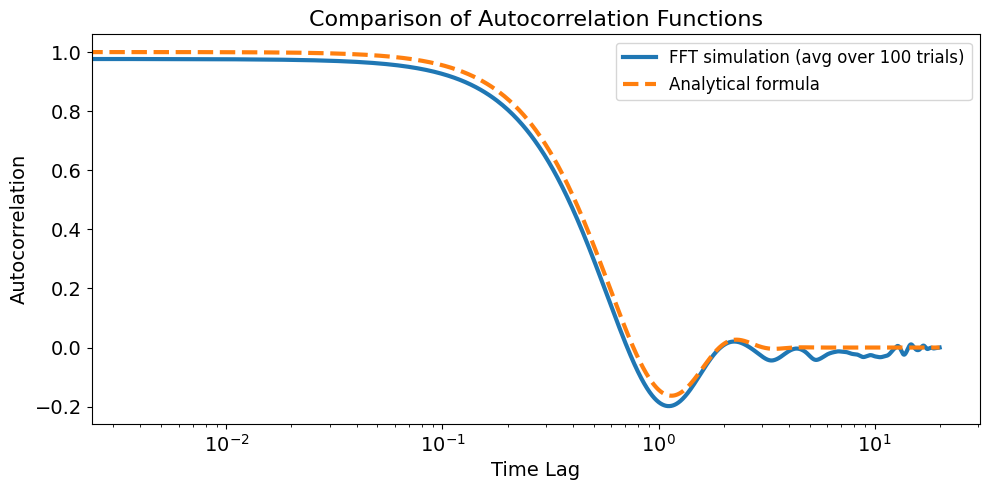

In [9]:
# ---------------------
# Plotting the results.
# ---------------------
plt.figure(figsize=(10, 5))
plt.plot(lags, avg_fft_ac, label=f'FFT simulation (avg over {N_fft} trials)', linewidth=3)
# plt.plot(lags, avg_lin_ac, label=f'Linear system simulation (avg over {N_linear} trials)', linewidth=3)
plt.plot(lags, ac_analytical, label='Analytical formula', linestyle='--', linewidth=3)
plt.xscale('log')
plt.xlabel("Time Lag", fontsize=14)
plt.ylabel("Autocorrelation", fontsize=14)
plt.title("Comparison of Autocorrelation Functions", fontsize=16)
plt.legend(fontsize=12)
# plt.grid(True, which="both", ls="--", lw=0.5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()
